# Análise de Sementes com Scikit Learn

## Importação de Bibliotecas
Importando bibliotecas para visualização e criação dos modelos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

## Carregamento e Exploração Inicial dos Dados
Carregar o conjunto de dados Seeds Dataset a partir do arquivo seeds_dataset.txt, exibir as primeiras linhas e informações sobre a estrutura dos dados.

In [3]:
column_names = [
    "Area", "Perimeter", "Compactness", "KernelLength", 
    "KernelWidth", "AsymmetryCoefficient", "KernelGrooveLength", "Class"
]

seeds_df = pd.read_csv('../data/seeds_dataset.txt', sep='\s+', names=column_names, header=None, encoding='utf-8')
seeds_df

,Area,Perimeter,Compactness,KernelLength,KernelWidth,AsymmetryCoefficient,KernelGrooveLength,Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
...,...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3


In [4]:
seeds_df.shape

(210, 8)

In [5]:
seeds_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Area                  210 non-null    float64
 1   Perimeter             210 non-null    float64
 2   Compactness           210 non-null    float64
 3   KernelLength          210 non-null    float64
 4   KernelWidth           210 non-null    float64
 5   AsymmetryCoefficient  210 non-null    float64
 6   KernelGrooveLength    210 non-null    float64
 7   Class                 210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


## Análise Estatística Descritiva
Calcular estatísticas descritivas (média, mediana, desvio padrão, mínimo, máximo) para cada característica dos grãos.

In [6]:
descriptive_stats = seeds_df.describe().T
descriptive_stats['median'] = seeds_df.median()
descriptive_stats

,count,mean,std,min,25%,50%,75%,max,median
Area,210.0,14.847524,2.909699,10.5900,12.27000,14.35500,17.305000,21.1800,14.35500
Perimeter,210.0,14.559286,1.305959,12.4100,13.45000,14.32000,15.715000,17.2500,14.32000
Compactness,210.0,0.870999,0.023629,0.8081,0.85690,0.87345,0.887775,0.9183,0.87345
KernelLength,210.0,5.628533,0.443063,4.8990,5.26225,5.52350,5.979750,6.6750,5.52350
KernelWidth,210.0,3.258605,0.377714,2.6300,2.94400,3.23700,3.561750,4.0330,3.23700
AsymmetryCoefficient,210.0,3.700201,1.503557,0.7651,2.56150,3.59900,4.768750,8.4560,3.59900
KernelGrooveLength,210.0,5.408071,0.491480,4.5190,5.04500,5.22300,5.877000,6.5500,5.22300
Class,210.0,2.000000,0.818448,1.0000,1.00000,2.00000,3.000000,3.0000,2.00000


## Visualização da Distribuição das Características
Criação de graficos (histograma e boxplot) da distribuição de cada característica e identificar possíveis outliers.

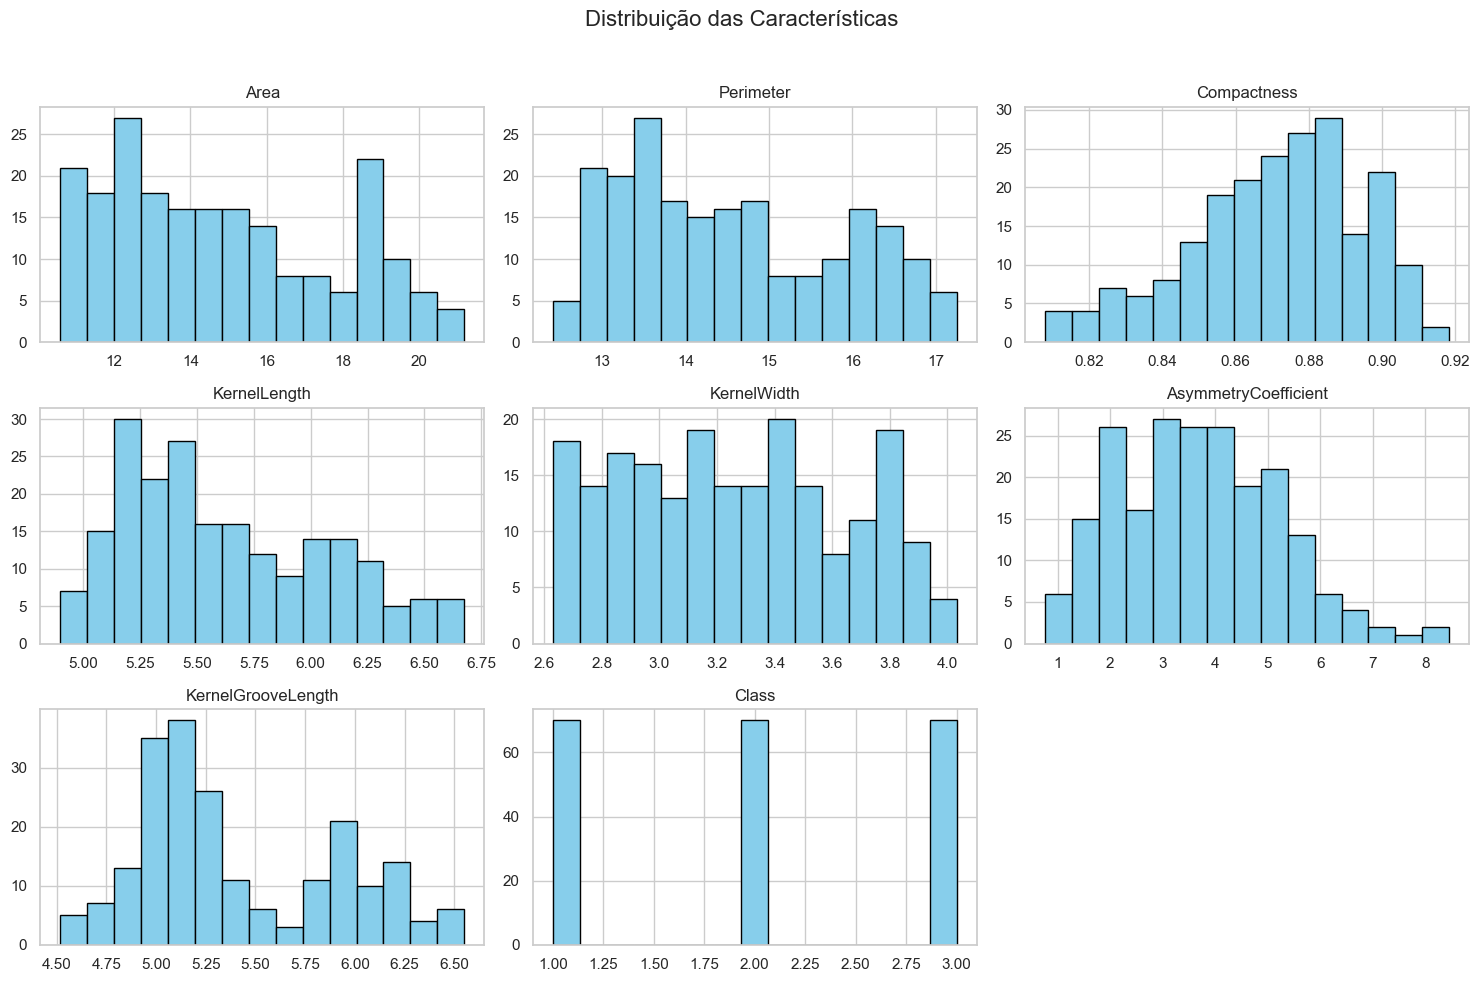

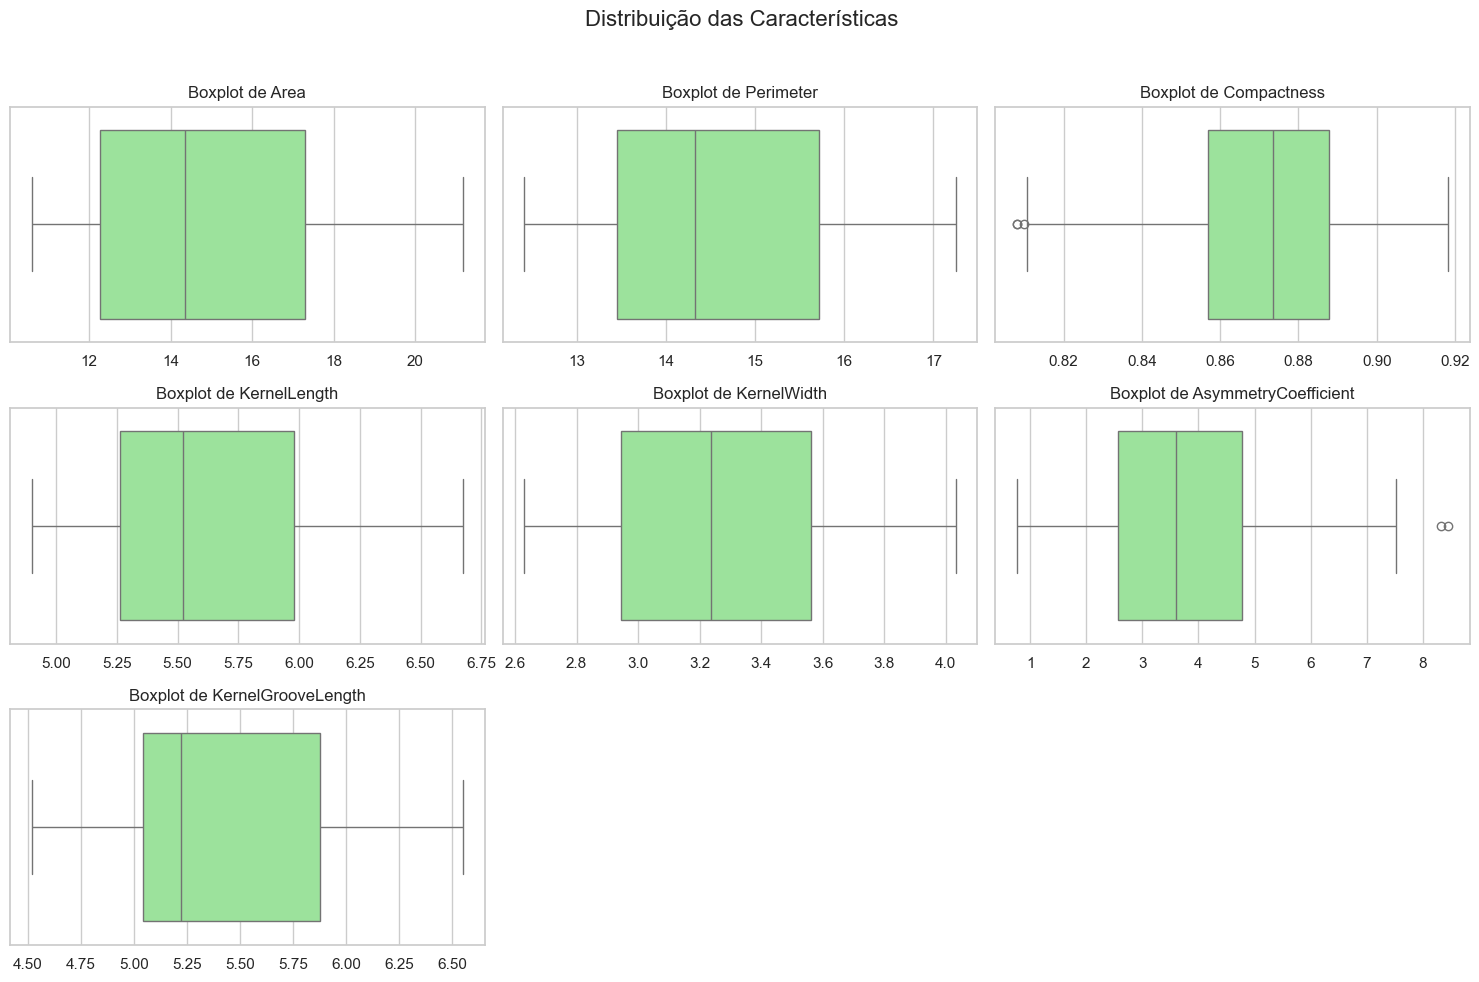

In [7]:
sns.set(style="whitegrid")

seeds_df.hist(bins=15, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle("Distribuição das Características", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

plt.figure(figsize=(15, 10))
for i, column in enumerate(seeds_df.columns[:-1]):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(data=seeds_df, x=column, color='lightgreen')
    plt.title(f"Boxplot de {column}")
    plt.xlabel("")
plt.suptitle("Distribuição das Características", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Análise de Correlação entre Características
Gerando Matriz de correlação para identificar relações entre variaveis

In [10]:
correlation_matrix = seeds_df.corr()
correlation_matrix

,Area,Perimeter,Compactness,KernelLength,KernelWidth,AsymmetryCoefficient,KernelGrooveLength,Class
Area,1.000000,0.994341,0.608288,0.949985,0.970771,-0.229572,0.863693,-0.346058
Perimeter,0.994341,1.000000,0.529244,0.972422,0.944829,-0.217340,0.890784,-0.327900
Compactness,0.608288,0.529244,1.000000,0.367915,0.761635,-0.331471,0.226825,-0.531007
KernelLength,0.949985,0.972422,0.367915,1.000000,0.860415,-0.171562,0.932806,-0.257269
KernelWidth,0.970771,0.944829,0.761635,0.860415,1.000000,-0.258037,0.749131,-0.423463
AsymmetryCoefficient,-0.229572,-0.217340,-0.331471,-0.171562,-0.258037,1.000000,-0.011079,0.577273
KernelGrooveLength,0.863693,0.890784,0.226825,0.932806,0.749131,-0.011079,1.000000,0.024301
Class,-0.346058,-0.327900,-0.531007,-0.257269,-0.423463,0.577273,0.024301,1.000000


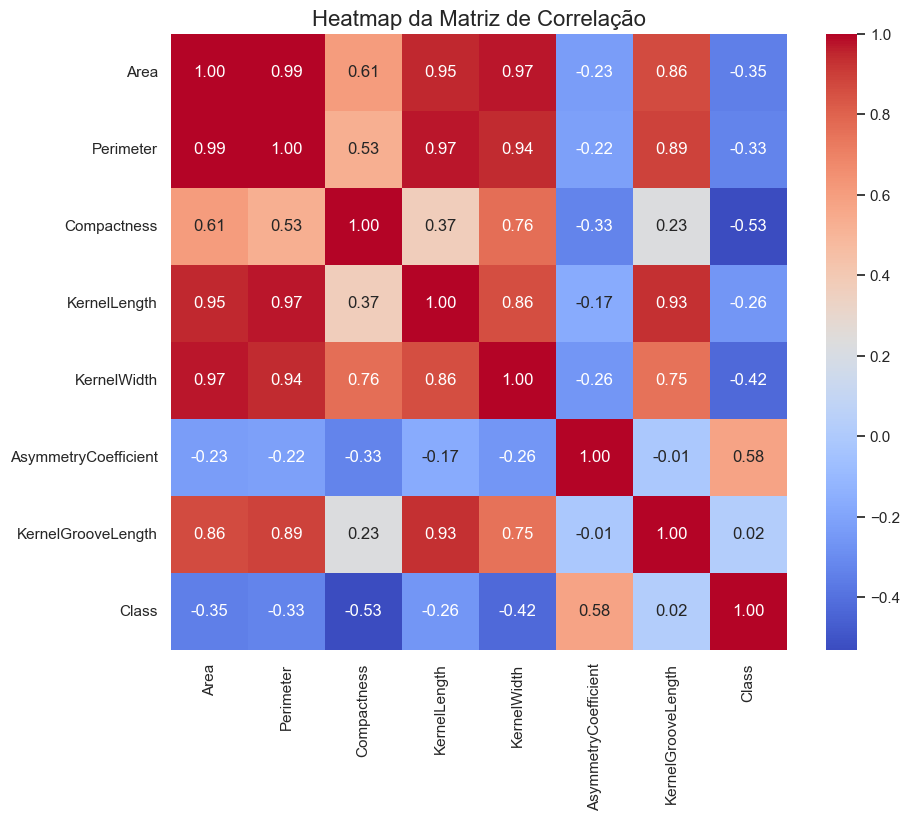

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Heatmap da Matriz de Correlação", fontsize=16)
plt.show()

Possivel verificar a colineridade entre multiplas features, como a Area em relação com Perimetro, largura e altura do espaço (núcleo). Modelos mais simples como Regressão Linear e o SVM sofrem com esse tipo de multicolineridade, pois não conseguem identificar qual feature contríbui mais para tal resultado, e pequenas mudanças em uma das features pode impactar nos coeficientes.

Criando grafico de dispersão das variaveis em relação a cada classe

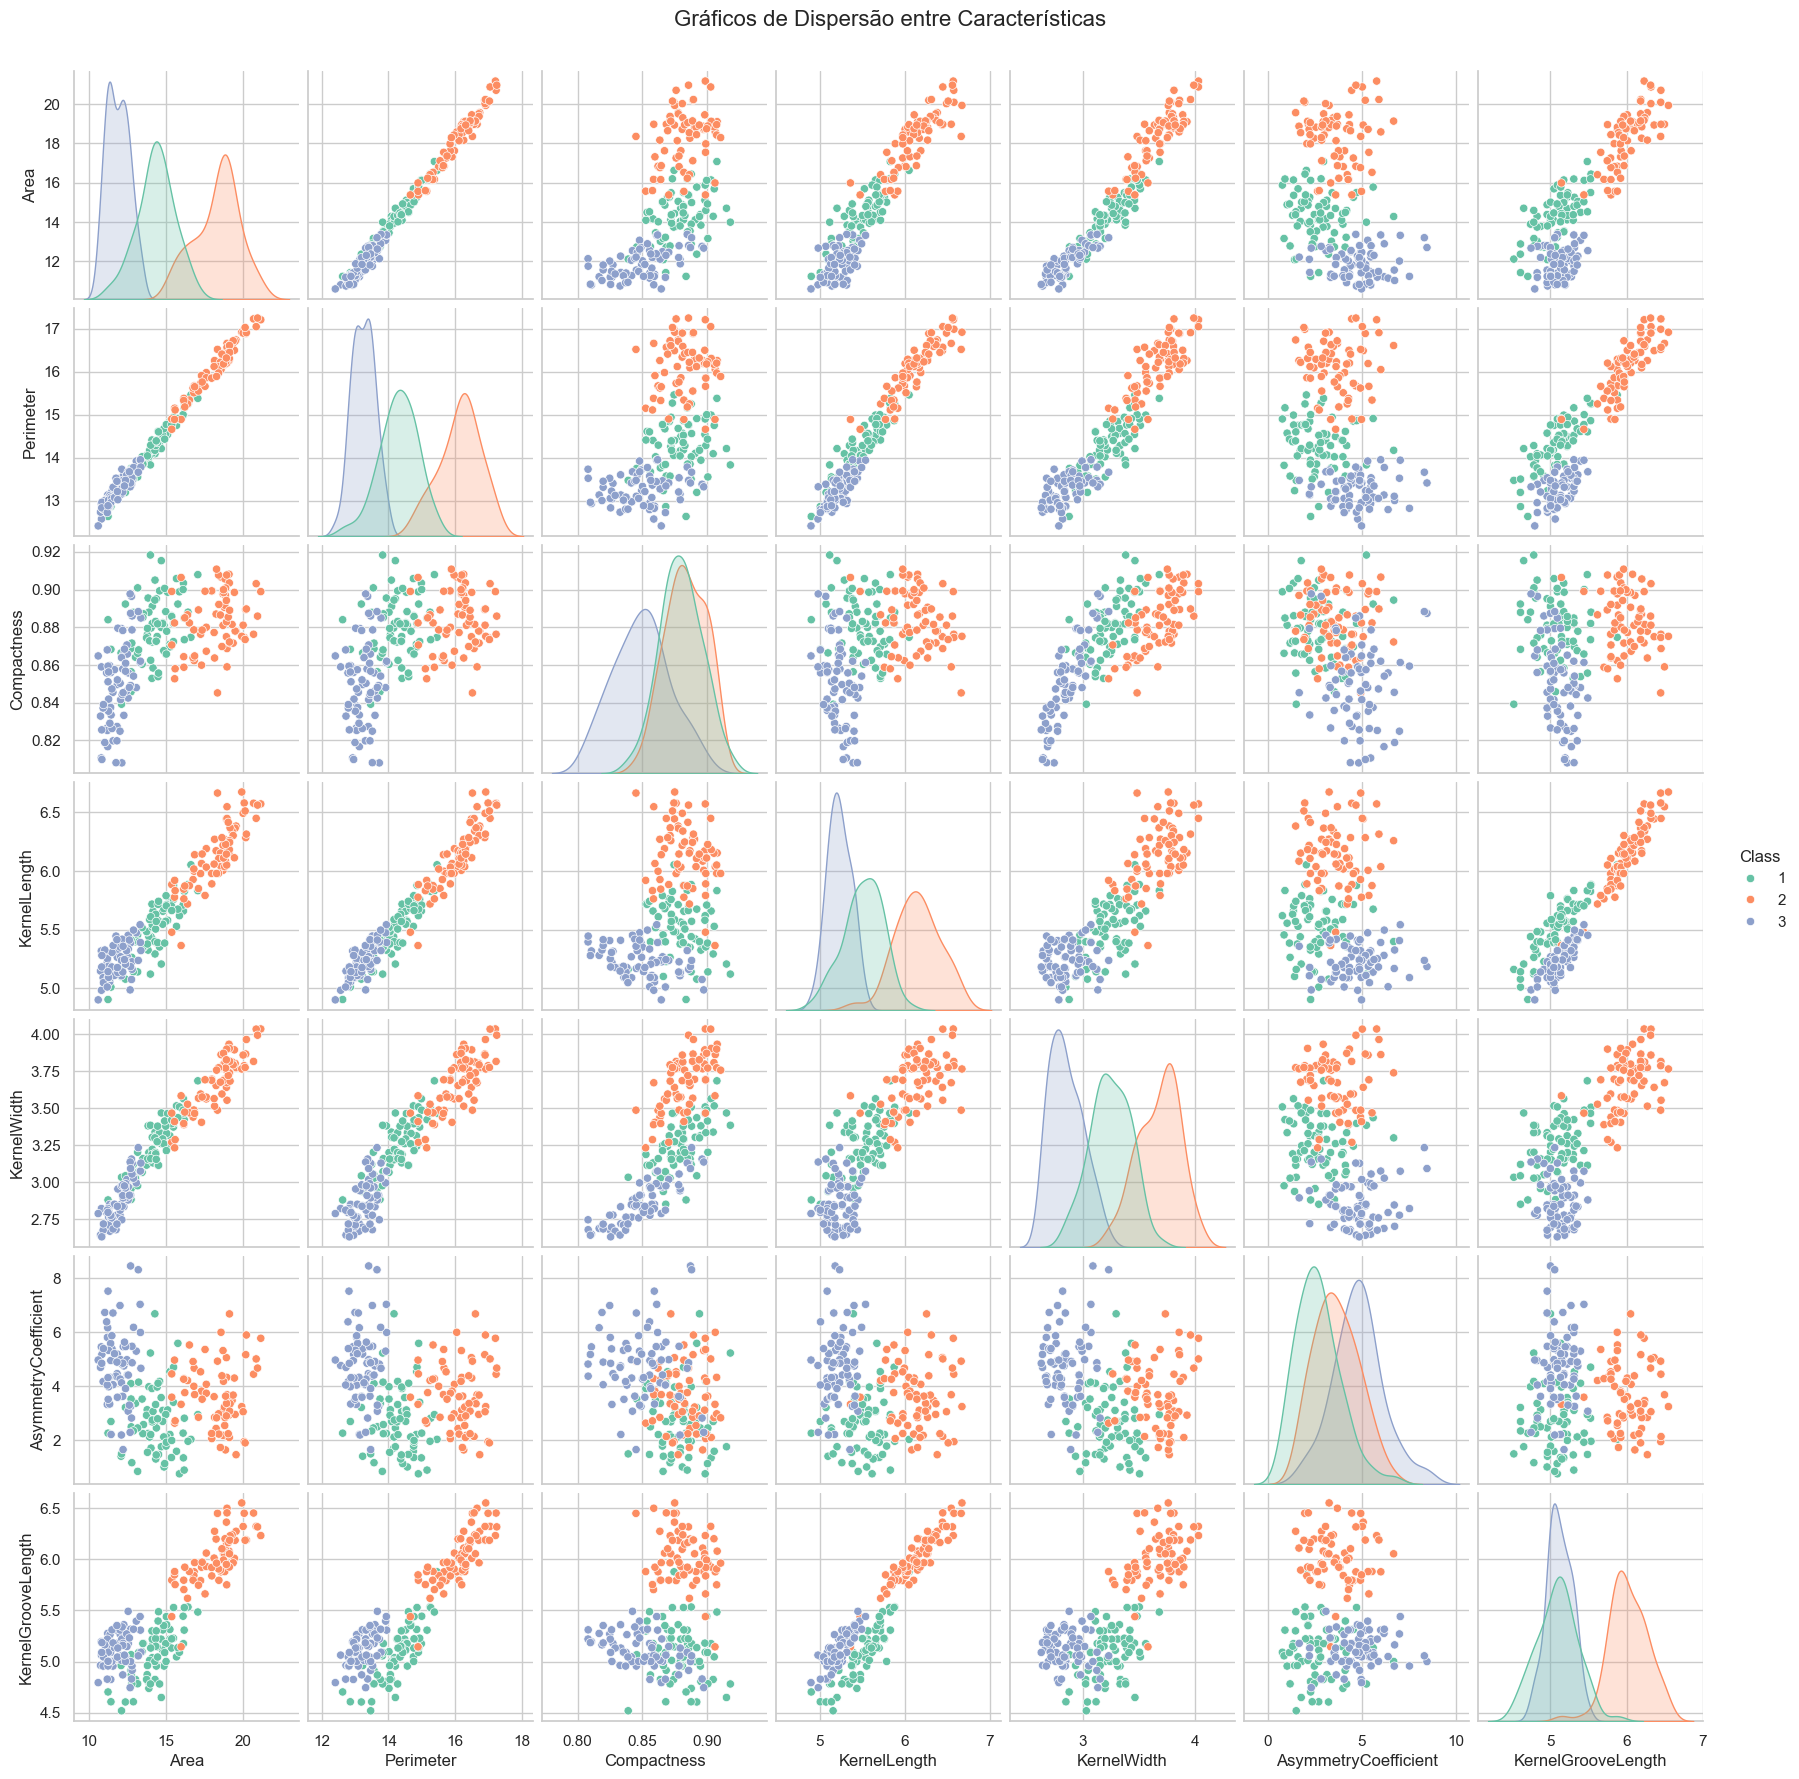

In [ ]:
pairplot = sns.pairplot(seeds_df, hue="Class", diag_kind="kde", palette="Set2")
pairplot.figure.suptitle("Gráficos de Dispersão entre Características", fontsize=16, y=1.02)
plt.show()

Para a semente "Kama" (classe 1) é possivel perceber uma area maior. No geral, a relação das variaveis está bem distinta, somente pela visualização dos dados já é possivel distinguir bem grupos de classes.

## Tratamento de Valores Ausentes
Verificando a presença de valores ausentes no dataset

In [16]:
missing_values = seeds_df.isnull().sum()
print(missing_values)

Area                    0
Perimeter               0
Compactness             0
KernelLength            0
KernelWidth             0
AsymmetryCoefficient    0
KernelGrooveLength      0
Class                   0
dtype: int64


## Normalização e Padronização dos Dados
Aplicando técnicas de escalonamento como StandardScaler ou MinMaxScaler para normalizar as características e preparar os dados para os modelos

In [17]:
from sklearn.preprocessing import MinMaxScaler

X = seeds_df.iloc[:, :-1]
y = seeds_df.iloc[:, -1]

scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

X_normalized_df = pd.DataFrame(X_normalized, columns=column_names[:-1])
X_normalized_df.head()

,Area,Perimeter,Compactness,KernelLength,KernelWidth,AsymmetryCoefficient,KernelGrooveLength
0,0.440982,0.502066,0.570780,0.486486,0.486101,0.189302,0.345150
1,0.405099,0.446281,0.662432,0.368806,0.501069,0.032883,0.215165
2,0.349386,0.347107,0.879310,0.220721,0.503920,0.251453,0.150665
3,0.306893,0.316116,0.793103,0.239302,0.533856,0.194243,0.140817
4,0.524079,0.533058,0.864791,0.427365,0.664291,0.076701,0.322994


In [18]:
standard_scaler = StandardScaler()
X_standardized = standard_scaler.fit_transform(X)

X_standardized_df = pd.DataFrame(X_standardized, columns=column_names[:-1])
X_standardized_df

,Area,Perimeter,Compactness,KernelLength,KernelWidth,AsymmetryCoefficient,KernelGrooveLength
0,0.142098,0.215462,0.000061,0.304218,0.141702,-0.986152,-0.383577
1,0.011188,0.008224,0.428515,-0.168625,0.197432,-1.788166,-0.922013
2,-0.192067,-0.360201,1.442383,-0.763637,0.208048,-0.667479,-1.189192
3,-0.347091,-0.475333,1.039381,-0.688978,0.319508,-0.960818,-1.229983
4,0.445257,0.330595,1.374509,0.066666,0.805159,-1.563495,-0.475356
...,...,...,...,...,...,...,...
205,-0.915515,-1.043321,0.309736,-1.112048,-0.736716,-0.046135,-1.097413
206,-1.246235,-1.288937,-0.844122,-1.105261,-1.230328,0.416540,-0.826156
207,-0.567571,-0.690247,0.733948,-0.888070,-0.070604,3.076588,-0.718060
208,-1.036090,-1.035645,-0.801701,-1.026077,-1.121521,-0.068135,-0.742535


## Divisão dos Dados em Conjuntos de Treinamento e Teste
Dividindo o conjunto de dados em conjuntos de treinamento (70%) e teste (30%).

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_standardized, y, test_size=0.3, random_state=42, stratify=y
)

print("Treinamento:", X_train.shape[0])
print("Teste:", X_test.shape[0])

Treinamento: 147
Teste: 63


## Implementação do Modelo K-Nearest Neighbors (KNN)

Relatório Geral:
              precision    recall  f1-score   support

           1       0.84      0.76      0.80        21
           2       0.90      0.90      0.90        21
           3       0.87      0.95      0.91        21

    accuracy                           0.87        63
   macro avg       0.87      0.87      0.87        63
weighted avg       0.87      0.87      0.87        63



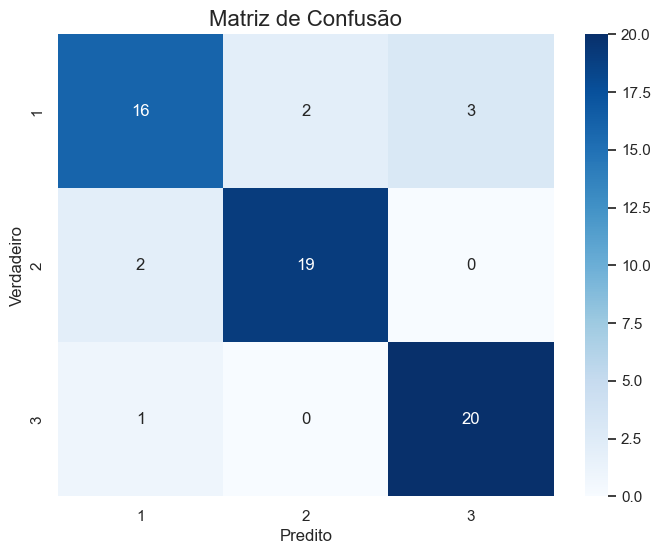

In [26]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("Relatório Geral:")
print(classification_report(y_test, y_pred_knn))

conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_knn, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title("Matriz de Confusão", fontsize=16)
plt.xlabel("Predito")
plt.ylabel("Verdadeiro")
plt.show()

Como visto na distribuição de funcionalidades, a dispersão não é tão grande entre classes, dessa forma o KNN é uma das opções mais simples para esse problema.

## Implementação do Modelo Support Vector Machine (SVM)

Relatório Geral:
              precision    recall  f1-score   support

           1       0.84      0.76      0.80        21
           2       0.90      0.90      0.90        21
           3       0.87      0.95      0.91        21

    accuracy                           0.87        63
   macro avg       0.87      0.87      0.87        63
weighted avg       0.87      0.87      0.87        63



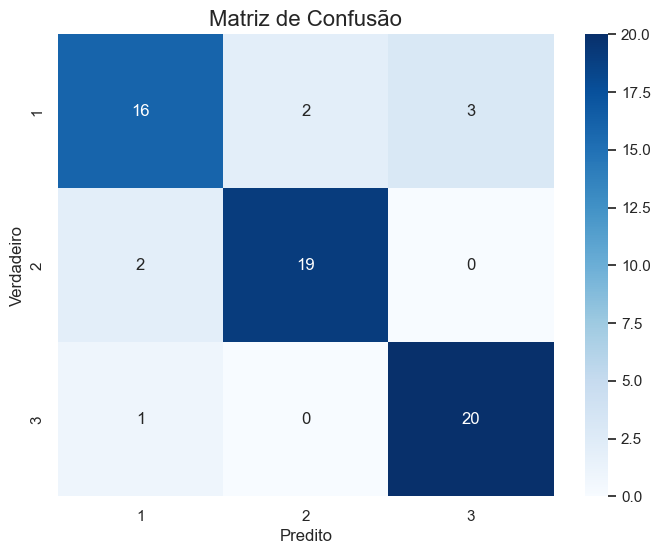

In [25]:
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("Relatório Geral:")
print(classification_report(y_test, y_pred_svm))

conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title("Matriz de Confusão", fontsize=16)
plt.xlabel("Predito")
plt.ylabel("Verdadeiro")
plt.show()

## Implementação do Modelo Random Forest
Implementar e treinar o modelo Random Forest utilizando o conjunto de treinamento e fazer predições no conjunto de teste.

Relatório Geral:
              precision    recall  f1-score   support

           1       0.94      0.81      0.87        21
           2       0.95      0.95      0.95        21
           3       0.88      1.00      0.93        21

    accuracy                           0.92        63
   macro avg       0.92      0.92      0.92        63
weighted avg       0.92      0.92      0.92        63



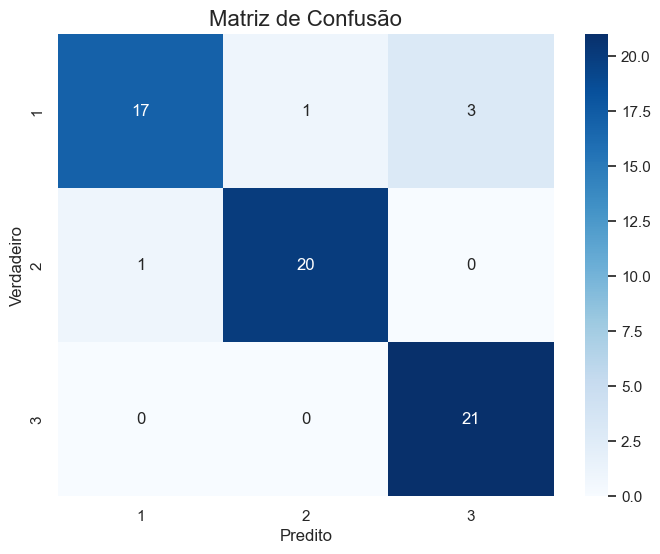

In [57]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Relatório Geral:")
print(classification_report(y_test, y_pred_rf))

conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title("Matriz de Confusão", fontsize=16)
plt.xlabel("Predito")
plt.ylabel("Verdadeiro")
plt.show()

## Otimização de Hiperparâmetros com Grid Search
Utilizando GridSearchCV para encontrar os melhores hiperparâmetros para cada modelo e retreinar os modelos otimizados.

In [37]:
def evaluate_model(model_name, y_true, y_pred):
    print(f"Relatório Geral para {model_name}:")
    print(classification_report(y_true, y_pred))
    
    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.title(f"Matriz de Confusão para {model_name}", fontsize=16)
    plt.xlabel("Predito")
    plt.ylabel("Verdadeiro")
    plt.show()

Melhores hiperparâmetros para KNN: {'n_neighbors': 9, 'weights': 'uniform'}
Melhores hiperparâmetros para SVM: {'C': 10, 'kernel': 'linear'}
Melhores hiperparâmetros para Random Forest: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}

Avaliação dos modelos otimizados:
Relatório Geral para KNN Otimizado:
              precision    recall  f1-score   support

           1       0.85      0.81      0.83        21
           2       0.90      0.90      0.90        21
           3       0.91      0.95      0.93        21

    accuracy                           0.89        63
   macro avg       0.89      0.89      0.89        63
weighted avg       0.89      0.89      0.89        63



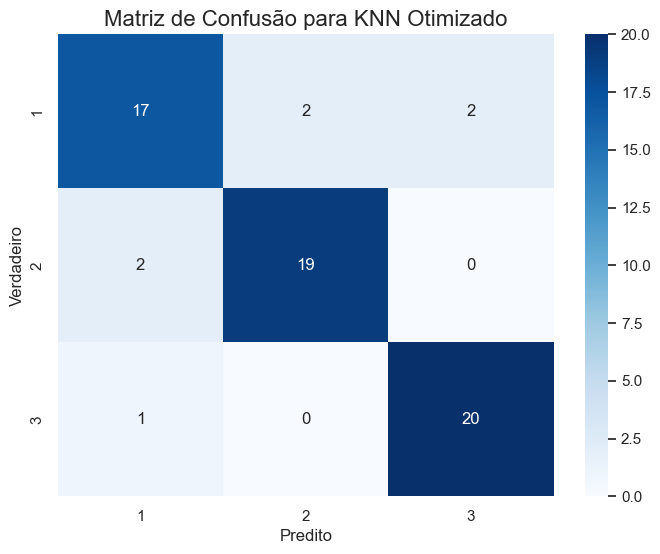

Relatório Geral para SVM Otimizado:
              precision    recall  f1-score   support

           1       0.81      0.81      0.81        21
           2       0.95      0.86      0.90        21
           3       0.87      0.95      0.91        21

    accuracy                           0.87        63
   macro avg       0.88      0.87      0.87        63
weighted avg       0.88      0.87      0.87        63



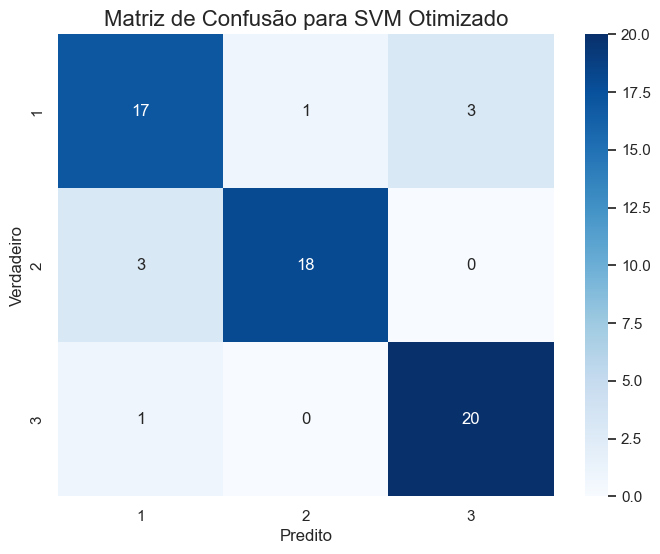

Relatório Geral para Random Forest Otimizado:
              precision    recall  f1-score   support

           1       0.89      0.76      0.82        21
           2       0.95      0.95      0.95        21
           3       0.83      0.95      0.89        21

    accuracy                           0.89        63
   macro avg       0.89      0.89      0.89        63
weighted avg       0.89      0.89      0.89        63



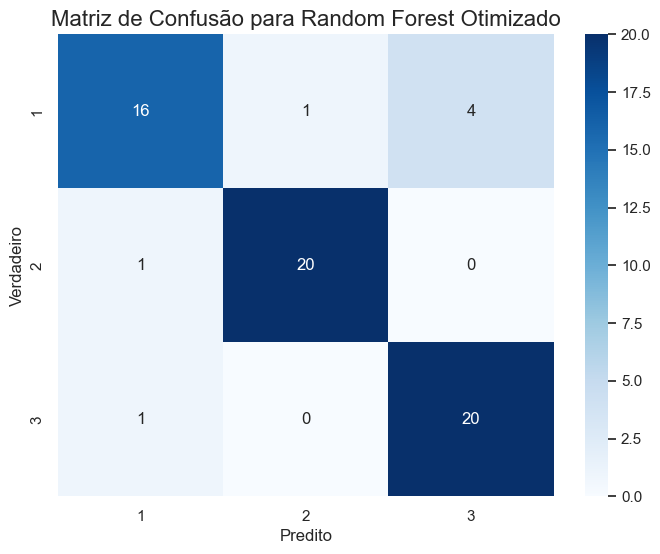

In [38]:
from sklearn.model_selection import GridSearchCV

knn_params = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
knn_grid_search = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='accuracy')
knn_grid_search.fit(X_train, y_train)

best_knn_model = knn_grid_search.best_estimator_
print("Melhores hiperparâmetros para KNN:", knn_grid_search.best_params_)

svm_params = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
svm_grid_search = GridSearchCV(SVC(random_state=42), svm_params, cv=5, scoring='accuracy')
svm_grid_search.fit(X_train, y_train)

best_svm_model = svm_grid_search.best_estimator_
print("Melhores hiperparâmetros para SVM:", svm_grid_search.best_params_)

rf_params = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]}
rf_grid_search = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='accuracy')
rf_grid_search.fit(X_train, y_train)

best_rf_model = rf_grid_search.best_estimator_
print("Melhores hiperparâmetros para Random Forest:", rf_grid_search.best_params_)

print("\nAvaliação dos modelos otimizados:")

y_pred_knn_optimized = best_knn_model.predict(X_test)
evaluate_model("KNN Otimizado", y_test, y_pred_knn_optimized)

y_pred_svm_optimized = best_svm_model.predict(X_test)
evaluate_model("SVM Otimizado", y_test, y_pred_svm_optimized)

y_pred_rf_optimized = best_rf_model.predict(X_test)
evaluate_model("Random Forest Otimizado", y_test, y_pred_rf_optimized)

## Avaliação dos Modelos Otimizados
Avaliando novamente os modelos otimizados utilizando as mesmas métricas de desempenho para verificar melhorias

Relatório Geral para KNN Otimizado:
              precision    recall  f1-score   support

           1       0.85      0.81      0.83        21
           2       0.90      0.90      0.90        21
           3       0.91      0.95      0.93        21

    accuracy                           0.89        63
   macro avg       0.89      0.89      0.89        63
weighted avg       0.89      0.89      0.89        63



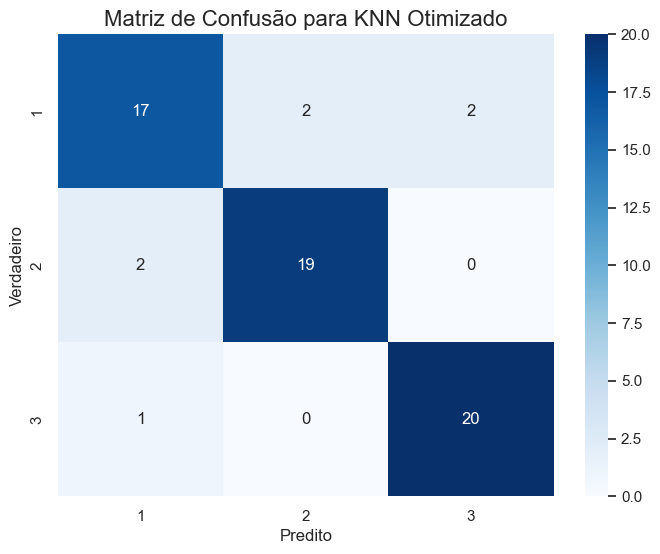

Relatório Geral para SVM Otimizado:
              precision    recall  f1-score   support

           1       0.81      0.81      0.81        21
           2       0.95      0.86      0.90        21
           3       0.87      0.95      0.91        21

    accuracy                           0.87        63
   macro avg       0.88      0.87      0.87        63
weighted avg       0.88      0.87      0.87        63



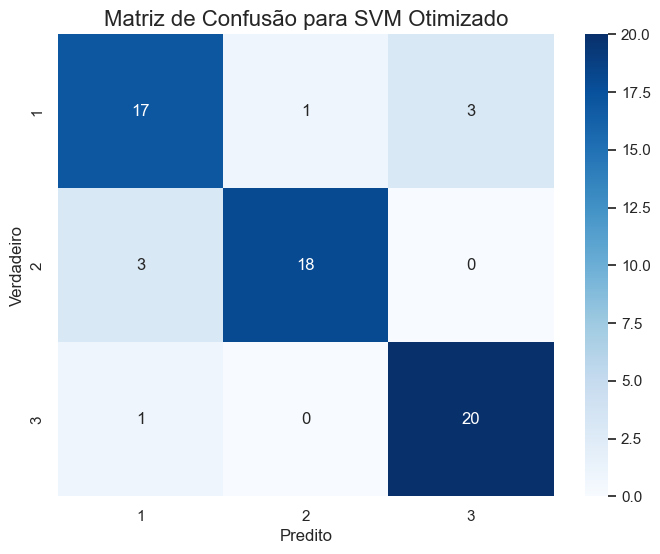

Relatório Geral para Random Forest Otimizado:
              precision    recall  f1-score   support

           1       0.89      0.76      0.82        21
           2       0.95      0.95      0.95        21
           3       0.83      0.95      0.89        21

    accuracy                           0.89        63
   macro avg       0.89      0.89      0.89        63
weighted avg       0.89      0.89      0.89        63



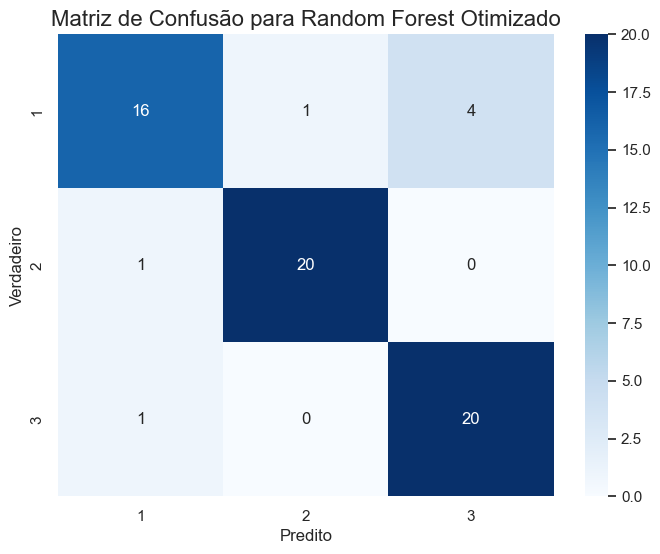

In [39]:
y_pred_knn_optimized = best_knn_model.predict(X_test)
evaluate_model("KNN Otimizado", y_test, y_pred_knn_optimized)

y_pred_svm_optimized = best_svm_model.predict(X_test)
evaluate_model("SVM Otimizado", y_test, y_pred_svm_optimized)

y_pred_rf_optimized = best_rf_model.predict(X_test)
evaluate_model("Random Forest Otimizado", y_test, y_pred_rf_optimized)

## Análise Comparativa Final dos Resultados
Comparação dos resultados antes e depois da otimização

In [42]:
performance_comparison = pd.DataFrame({
    "Modelo": ["KNN", "SVM", "Random Forest", "KNN Otimizado", "SVM Otimizado", "Random Forest Otimizado"],
    "Acurácia": [
        knn_grid_search.best_score_, 
        svm_grid_search.best_score_, 
        rf_grid_search.best_score_, 
        classification_report(y_test, y_pred_knn_optimized, output_dict=True)['accuracy'],
        classification_report(y_test, y_pred_svm_optimized, output_dict=True)['accuracy'],
        classification_report(y_test, y_pred_rf_optimized, output_dict=True)['accuracy']
    ],
    "Precisão Média": [
        classification_report(y_test, y_pred_knn, output_dict=True)['weighted avg']['precision'],
        classification_report(y_test, y_pred_svm, output_dict=True)['weighted avg']['precision'],
        classification_report(y_test, y_pred_rf, output_dict=True)['weighted avg']['precision'],
        classification_report(y_test, y_pred_knn_optimized, output_dict=True)['weighted avg']['precision'],
        classification_report(y_test, y_pred_svm_optimized, output_dict=True)['weighted avg']['precision'],
        classification_report(y_test, y_pred_rf_optimized, output_dict=True)['weighted avg']['precision']
    ],
    "Recall Médio": [
        classification_report(y_test, y_pred_knn, output_dict=True)['weighted avg']['recall'],
        classification_report(y_test, y_pred_svm, output_dict=True)['weighted avg']['recall'],
        classification_report(y_test, y_pred_rf, output_dict=True)['weighted avg']['recall'],
        classification_report(y_test, y_pred_knn_optimized, output_dict=True)['weighted avg']['recall'],
        classification_report(y_test, y_pred_svm_optimized, output_dict=True)['weighted avg']['recall'],
        classification_report(y_test, y_pred_rf_optimized, output_dict=True)['weighted avg']['recall']
    ],
    "F1-Score Médio": [
        classification_report(y_test, y_pred_knn, output_dict=True)['weighted avg']['f1-score'],
        classification_report(y_test, y_pred_svm, output_dict=True)['weighted avg']['f1-score'],
        classification_report(y_test, y_pred_rf, output_dict=True)['weighted avg']['f1-score'],
        classification_report(y_test, y_pred_knn_optimized, output_dict=True)['weighted avg']['f1-score'],
        classification_report(y_test, y_pred_svm_optimized, output_dict=True)['weighted avg']['f1-score'],
        classification_report(y_test, y_pred_rf_optimized, output_dict=True)['weighted avg']['f1-score']
    ]
})

print("Comparação de Desempenho:")
print(performance_comparison)

Comparação de Desempenho:
                    Modelo  Acurácia  Precisão Média  Recall Médio  \
0                      KNN  0.932184        0.872144      0.873016   
1                      SVM  0.965977        0.872144      0.873016   
2            Random Forest  0.905517        0.923942      0.920635   
3            KNN Otimizado  0.888889        0.887951      0.888889   
4            SVM Otimizado  0.873016        0.875486      0.873016   
5  Random Forest Otimizado  0.888889        0.891534      0.888889   

   F1-Score Médio  
0        0.871284  
1        0.871284  
2        0.919170  
3        0.888088  
4        0.872872  
5        0.887261  
